## On the use of hierarchical Bayesian modelling for stochastic crack growth monitoring

### Case 1 - Modelling stochastic crack growth using a modified Paris' law model: a general description

This notebook describes a framework for modelling stochastic crack growth using a modified version of Paris' law, which involves a time-discretisation during the crack propagation phase and the application of the conventional Paris' law for each time interval. This modified version of the Paris law model is inspired by structures subjected to operational conditions leading to time-varying fatigue loads, which lead to steady state conditions for considerable amounts of time. The objective behind this modelling choice is twofold: to predict crack growth more accurately and to provide a model that is amenable to hierarchical Bayesian modelling, which can be used to improve inference of time-invariant parameters (fixed effects) in the Paris' law model, which conventionally suffers from identifiability issues.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys
import numpy as np

notebook_path = Path().absolute()
project_root = notebook_path.parent
sys.path.append(str(project_root))
from src.data_utils import SCGDataLoader
from src.visualisation import plot_paris_predictions


First, we will load some stochastic crack growth data from another simulation to take advantage of the available simulation parameters which will lead to a physically meaningful demonstration. 

In [3]:
data_loader = SCGDataLoader()
data = data_loader.load_data()

In [4]:
# Randomly select instances to test the Paris law predictions
instances = np.random.randint(low=0, high=(data["times"].shape[0] - 1), size=10)
# Get the Paris law parameters for these instances
paris_params = (data["paris_c"][instances], data["paris_m"][instances])
# Get the initial crack lengths for these instances
initial_crack_lengths = data["initial_crack_length"][instances]
# Get the stress ranges for these instances
stress_ranges = np.linspace(10, 40, instances.shape[0])
# Use a common time array for all instances - using the first row of times
time_array = data["times"][0]
# Create array with the number of cycles for each instance
n_cycles = np.ones(instances.shape[0]) * np.mean(data["avg_cycles"][:, 0])

Now, we can use this data to generate different crack growth instances using the conventional Paris law model.

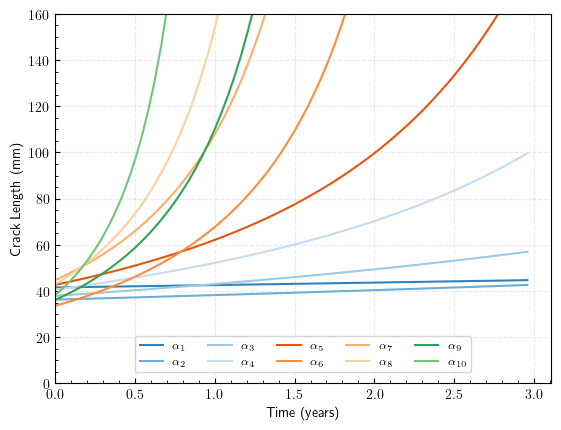

In [177]:
# Use our refactored function for plotting
fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=n_cycles,
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="paris_predictions.pdf",
    figsize=(6.4, 4.8),
    plot_grid=True
)

# We can add additional customization if needed
#ax.set_title("Paris Law Crack Growth Predictions for Multiple Instances")

Parameters for instance 5734:
logC: -29.8671
m: 3.0990
ds: 23.3333
navg: 2793155.5950
a0: 42.6700


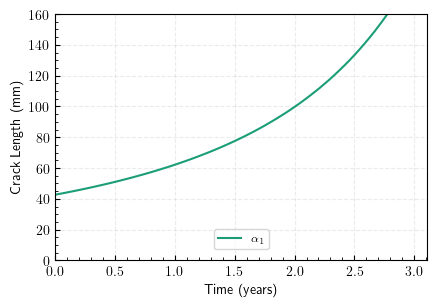

In [178]:
# Let's also test a single prediction to understand what's going on
inst = instances[4]
c = paris_params[0][4]
m = paris_params[1][4]
ds = stress_ranges[4]
navg = n_cycles[4]
a0 = initial_crack_lengths[4]

# Print these values to debug
print(f"Parameters for instance {inst}:")
print(f"logC: {np.log(c):.4f}")
print(f"m: {m:.4f}")
print(f"ds: {ds:.4f}")
print(f"navg: {navg:.4f}")
print(f"a0: {a0:.4f}")

# Plot a single instance prediction
fig, ax = plot_paris_predictions(
    paris_params=(c, m),
    ds=ds,
    navg=navg,
    a0=a0,
    times=time_array,
    figsize=(4.8, 3.2),
    cmap_name='Dark2'
)

We can also take a look at the sensitivity of Paris law with respect to the three main parameters that represent quantities of interest for us, namely the Paris law parameters $C, m$ and the stress range $\Delta S$.

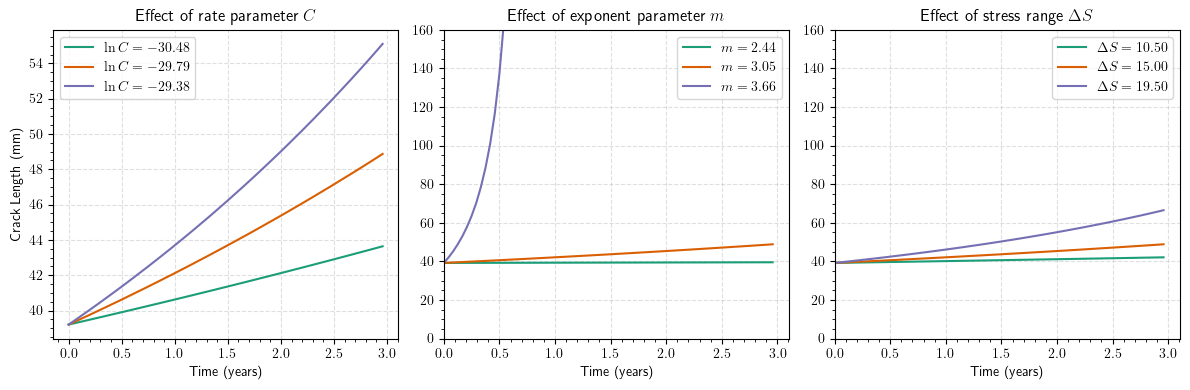

In [7]:
# Let's also explore how different parameters affect crack growth
from src.visualisation import plot_parameter_sensitivity

# Create baseline parameters
base_c = paris_params[0][0]
base_m = paris_params[1][0]
base_ds = 15.0
base_navg = n_cycles[0]
base_a0 = initial_crack_lengths[0]

# Use the new modular function for parameter sensitivity analysis
fig, axes = plot_parameter_sensitivity(
    base_c=base_c,
    base_m=base_m,
    base_ds=base_ds,
    base_navg=base_navg,
    base_a0=base_a0,
    times=time_array,
    save_fig_name="parameter_sensitivity.pdf",
)

# You can still customize the plot if needed
# axes[1].set_ylim(bottom=0, top=160)

## Testing Variable Stress Paris-Erdogan Model

This section demonstrates how to use the `VariableStressParisErdogan` model for simulating crack growth with time-varying stress ranges.

Average stress: 17.00 MPa
Stress range: 5.0 - 30.0 MPa


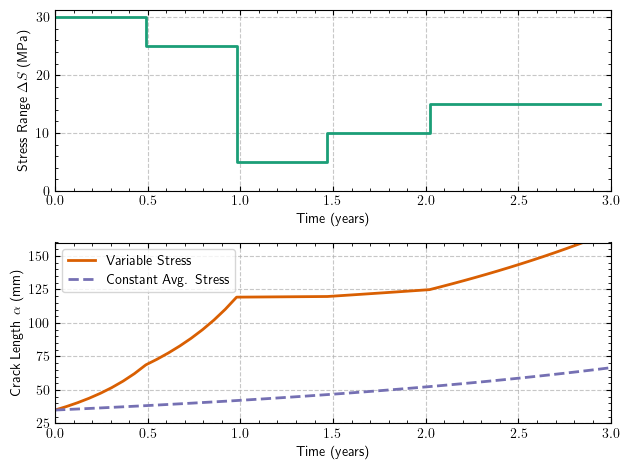

In [8]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 5.0),
    (1.5, 2.0, 10.0),
    (2.0, 3.0, 15.0),
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(1e-13),
    m=3.2,
    navg=3e6,
    a0=35.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name="variable_stress_comparison.pdf"
)

# Print some interesting statistics about the plot
print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

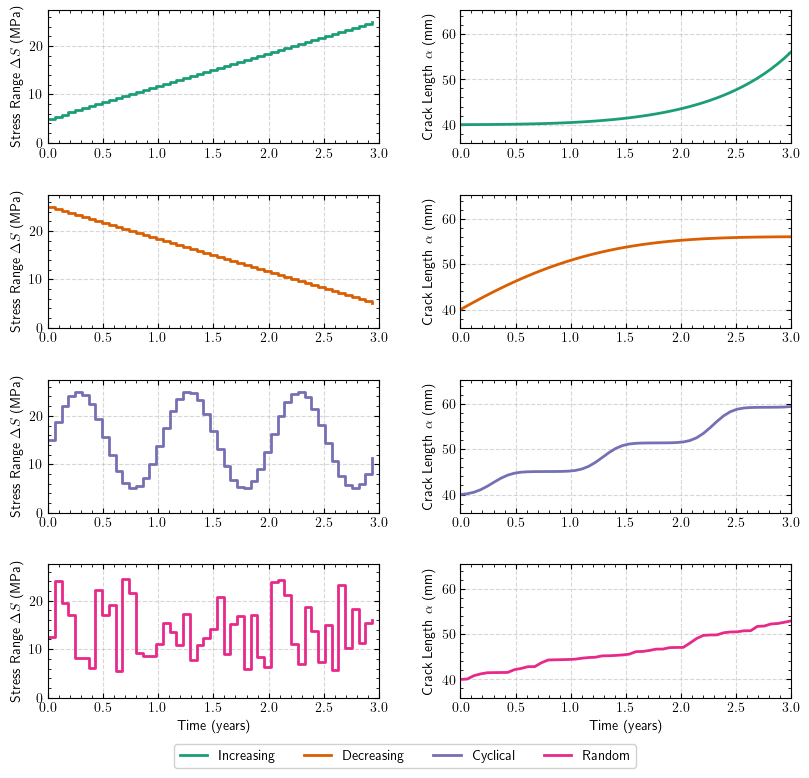

In [9]:
from src.visualisation import plot_stress_pattern_comparison

# Set parameters
logc = np.log(5e-14)  # Natural log of Paris law C parameter
m = 3.2               # Paris law exponent m
navg = 2.8e6          # Average cycles per year
a0 = 40.0             # Initial crack length (mm)

# Use the new function to create the comparison plot
fig, axes = plot_stress_pattern_comparison(
    logc=logc,
    m=m,
    navg=navg,
    a0=a0,
    min_stress=5.0,
    max_stress=25.0,
    patterns=['increasing', 'decreasing', 'cyclical', 'random'],
    cmap_name='Dark2',
    figsize=(8.2, 8.2),
    save_fig_name="stress_pattern_comparison.pdf"
)

# Print analysis of the results
# print("Final crack lengths with varying stress patterns:")
# for pattern, length in stats['final_lengths'].items():
#     print(f"{pattern.capitalize():<12}: {length:.2f} mm")

# print("\nAverage stress for each pattern:")
# for pattern, avg_stress in stats['avg_stresses'].items():
#     print(f"{pattern.capitalize():<12}: {avg_stress:.2f} MPa")

# print("\nEffect of stress pattern (Length/Stress ratio):")
# for pattern, ratio in stats['length_stress_ratio'].items():
#     print(f"{pattern.capitalize():<12}: {ratio:.2f}")

# # Explanation of why patterns with same average stress produce different results
# print("\nObservation: Even with the same average stress, patterns produce")
# print(r"different final crack lengths because of the power law $(da/dN ∝ \Delta K^m)$.")
# print(f"When $m > 1$ (here m = {m:.1f}), high stress periods contribute")
# print("disproportionately more to crack growth than low stress periods.")


## Demonstrating Single Task Learning with Multiple Components

In this section, we'll create three different components (tasks) with the same Paris law parameters but different initial crack lengths and stress ranges. This controlled scenario will allow us to later compare single-task vs. multi-task learning approaches.

In [5]:
import matplotlib.pyplot as plt

# Define common Paris law parameters for all components
common_logc = np.log(np.exp(-29.8)) # Natural logarithm of Paris C parameter
common_m = 3.12               # Paris law exponent
common_navg = 2.8e6          # Average cycles per year

# Define different initial crack lengths for the three components
initial_crack_lengths = np.array([41.0, 37.0, 39.0])

# Define different stress ranges for the three components
stress_ranges = np.array([16.0, 22., 19.0])

# Create a time array for predictions
time_array = np.linspace(0, 3.0, 72)

# Print the parameters for reference
print("Common parameters for all components:")
print(f"logC = {common_logc:.4f}")
print(f"m = {common_m:.4f}")
print(f"navg = {common_navg:.1f} cycles/year")
print("\nComponent-specific parameters:")
for i in range(3):
    print(f"Component {i+1}: Initial crack length = {initial_crack_lengths[i]:.2f} mm, Stress range = {stress_ranges[i]:.2f} MPa")

Common parameters for all components:
logC = -29.8000
m = 3.1200
navg = 2800000.0 cycles/year

Component-specific parameters:
Component 1: Initial crack length = 41.00 mm, Stress range = 16.00 MPa
Component 2: Initial crack length = 37.00 mm, Stress range = 22.00 MPa
Component 3: Initial crack length = 39.00 mm, Stress range = 19.00 MPa


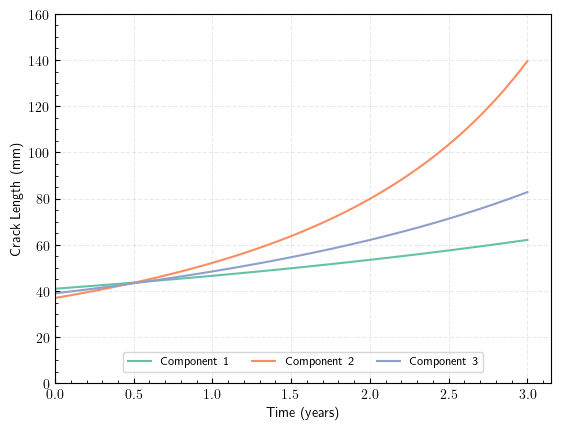

In [7]:
# Use plot_paris_predictions to visualize the crack growth for our components
from src.visualisation import plot_paris_predictions

# Convert logC to C for the paris_params format
common_c = np.exp(common_logc)
paris_params = (np.array([common_c, common_c, common_c]), 
               np.array([common_m, common_m, common_m]))

fig, ax = plot_paris_predictions(
    paris_params=paris_params,
    ds=stress_ranges,
    navg=np.array([common_navg, common_navg, common_navg]),
    a0=initial_crack_lengths,
    times=time_array,
    save_fig_name="controlled_components_growth.svg",
    figsize=(6.4, 4.8),
    plot_grid=True,
    cmap_name='Set2'
)

The plot above shows crack growth trajectories for three components that share the same Paris law parameters but have different initial conditions (crack length) and loading conditions (stress range). 

Component 2 shows the fastest growth rate due to its higher stress range, whilst Component 1 has the slowest growth. This controlled scenario is ideal for our hierarchical Bayesian modelling approach, as we have a known "ground truth" for the shared parameters.

In the next section, we'll generate simulated observations from these trajectories and perform Bayesian inference.

In [8]:
# Generate the full crack growth data for reference
from src.predictive_models import CrackGrowthPredictor

# Create predictor
predictor = CrackGrowthPredictor()

# Generate full crack growth trajectories
crack_lengths = np.zeros((3, len(time_array)))

for i in range(3):
    crack_lengths[i] = predictor.predict_crack_growth(
        logc=common_logc,
        m=common_m,
        ds=stress_ranges[i],
        navg=common_navg,
        a0=initial_crack_lengths[i],
        times=time_array
    )

# Save these trajectories for later use in Bayesian inference
controlled_data = {
    'times': time_array,
    'crack_lengths': crack_lengths,
    'paris_c': np.array([common_c, common_c, common_c]),
    'paris_m': np.array([common_m, common_m, common_m]),
    'initial_crack_length': initial_crack_lengths,
    'stress_ranges': stress_ranges,
    'navg': np.array([common_navg, common_navg, common_navg])
}

print(f"Generated crack length arrays with shape: {crack_lengths.shape}")
print(f"Final crack lengths after {time_array[-1]:.1f} years:")
for i in range(3):
    print(f"Component {i+1}: {crack_lengths[i, -1]:.2f} mm")

Generated crack length arrays with shape: (3, 72)
Final crack lengths after 3.0 years:
Component 1: 62.15 mm
Component 2: 139.59 mm
Component 3: 82.83 mm


Now, we can convert the `controlled_data` dictionary to a format that is consistent with what is expected by the `CrackObservationGenerator` class.

In [9]:
trajectories = {
    'times': [time_array for _ in range(3)],  # Same time array for all components
    'crack_lengths': [crack_lengths[i] for i in range(3)],
    'paris_c': controlled_data['paris_c'],
    'paris_m': controlled_data['paris_m'],
    'initial_crack_length': controlled_data['initial_crack_length']
}

We can now create an instance of the observation generator and generate some synthetic data which we'll use for inference. We will employ a uniform sampling over the monitoring lifetime and add some zero-mean Gaussian noise with a standard deviation of 1.5 mm.

In [63]:
from src.data_utils import CrackObservationGenerator

# Create observation generator with the formatted trajectories
obs_generator = CrackObservationGenerator(trajectories, random_seed=42)

# Generate uniform observations with moderate noise
obs = obs_generator.create_observations(
    n_points=[3, 5, 10],            # 8 observations per component
    strategy='uniform',    # Evenly spaced observations
    noise_std=1.5,           # 1.5mm standard deviation noise
    include_endpoints=False,
    random_seed=28
)

Let's plot our observations alongside the target crack growth trajectories to make sure everything is as expected.

In [64]:
from src.visualisation import plot_trajectories_with_observations

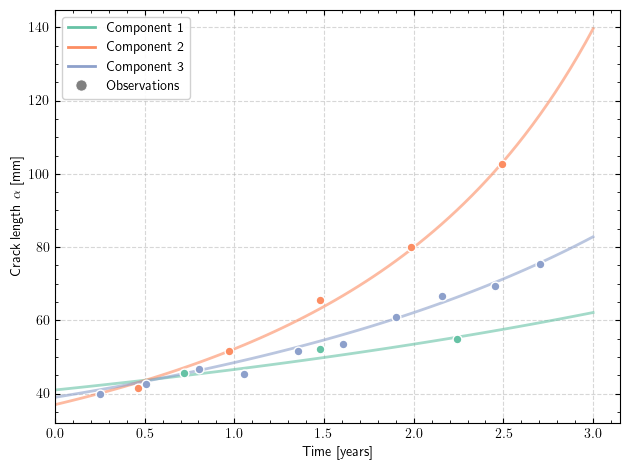

In [65]:
fig, ax = plot_trajectories_with_observations(
    times=trajectories['times'],
    crack_lengths=trajectories['crack_lengths'],
    obs_times=obs['times'],
    obs_lengths=obs['noisy_crack_lengths'],
    labels=[f"Component {i+1}" for i in range(3)],
    cmap_name='Set2',
    figsize=(6.4, 4.8),
    traj_alpha=0.6,
    obs_alpha=1.0,
    marker_size=40,
    save_fig_name="obs_classic_sparse.svg"
)


## Bayesian Inference for Crack Growth Parameters

In this section, we'll use the Bayesian model we've implemented to infer Paris law parameters from observed crack growth data. We'll start with a single component and then expand to multiple components.

In [66]:
import numpyro.distributions as dist
from src.bayesian_models import STLBayesianModel
from src.visualisation import plot_posterior_trace, plot_prior_posterior_comparison, plot_posterior_predictive_stl

# Set a seed for reproducibility
np.random.seed(42)

In [67]:
# First, let's define our priors for the model
# These priors are based on domain knowledge about Paris law parameters
priors = {
    "logc": dist.Normal(-30.0, 2.0),      # Natural log of C parameter
    "m": dist.HalfNormal(2.0),           # Paris law exponent
    "ds": dist.Weibull(14.9, 1.6),           # Stress range (MPa)
    "noise_std": dist.HalfNormal(2.0)     # Observation noise (mm)
}

In [87]:
# Component index to start with
component_idx = 2

# Extract the true parameters for this component from the selected trajectories
true_logc = np.log(trajectories['paris_c'][component_idx])
true_m = trajectories['paris_m'][component_idx]
true_a0 = trajectories['initial_crack_length'][component_idx]
true_ds = controlled_data['stress_ranges'][component_idx]

In [88]:
print(f"True parameters for component {component_idx + 1}:")
print(f"logC: {true_logc:.4f}")
print(f"m: {true_m:.4f}")
print(f"a0: {true_a0:.4f}")
print(f"ds: {true_ds:.4f} MPa")

True parameters for component 3:
logC: -29.8000
m: 3.1200
a0: 39.0000
ds: 19.0000 MPa


In [89]:
import warnings
warnings.filterwarnings("ignore")

In [90]:
# Create the Bayesian model
# We'll use the uniform observations we created earlier
model = STLBayesianModel(priors=priors, crack_growth_data=obs)

# Run inference with MCMC
# For demonstration, we're using fewer samples than we would in practice
results = model.run_inference(
    component_idx=component_idx,
    navg = 2.8e6,       # Average cycles per year
    num_warmup=2000,    # Number of warmup steps
    num_samples=2000,   # Number of samples to draw
    num_chains=4,       # Number of chains to run
    progress_bar=True   # Show progress bar during sampling
)

sample: 100%|██████████| 4000/4000 [00:01<00:00, 2020.95it/s, 87 steps of size 3.45e-03. acc. prob=0.98]  


In [82]:
# Print full posterior summary
model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")
print(f"Inferred logC: {results['summary']['mean']['logc']:.4f} ± {results['summary']['sd']['logc']:.4f}")
print(f"Inferred m: {results['summary']['mean']['m']:.4f} ± {results['summary']['sd']['m']:.4f}")
print(f"Inferred noise_std: {results['summary']['mean']['noise_std']:.4f} ± {results['summary']['sd']['noise_std']:.4f}")

                               mean     sd  hdi_3%  hdi_97%  mcse_mean  \
ds                           21.935  9.043   5.793   38.206      0.155   
logc                        -27.483  1.997 -31.236  -23.834      0.039   
m                             2.850  0.406   2.101    3.615      0.008   
noise_std                     3.842  0.970   2.108    5.667      0.018   
predicted_crack_lengths[0]   46.436  0.695  45.204   47.791      0.013   
predicted_crack_lengths[1]   59.426  1.411  56.709   61.996      0.026   
predicted_crack_lengths[2]   77.854  2.078  73.984   81.752      0.031   
predicted_crack_lengths[3]  105.029  3.495  98.809  111.894      0.042   

                            mcse_sd  ess_bulk  ess_tail  r_hat  
ds                            0.121  3134.613  3032.276  1.001  
logc                          0.026  2561.756  2931.892  1.003  
m                             0.007  2399.174  2596.353  1.003  
noise_std                     0.014  2951.734  3400.131  1.001  
predicte

In [91]:
model.check_rhat()

R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
ds                       : 1.0000 ✓ 
logc                     : 1.0000 ✓ 
m                        : 1.0000 ✓ 
noise_std                : 1.0000 ✓ 
predicted_crack_lengths[0]: 1.0000 ✓ 
predicted_crack_lengths[1]: 1.0000 ✓ 
predicted_crack_lengths[2]: 1.0000 ✓ 
predicted_crack_lengths[3]: 1.0000 ✓ 
predicted_crack_lengths[4]: 1.0000 ✓ 
predicted_crack_lengths[5]: 1.0000 ✓ 
predicted_crack_lengths[6]: 1.0000 ✓ 
predicted_crack_lengths[7]: 1.0000 ✓ 
predicted_crack_lengths[8]: 1.0000 ✓ 

Convergence Summary:
Parameters with R-hat ≤ 1.01: 13/13
Convergence rate: 100.0%
Max R-hat: 1.0000
✅ All variable parameters have converged!


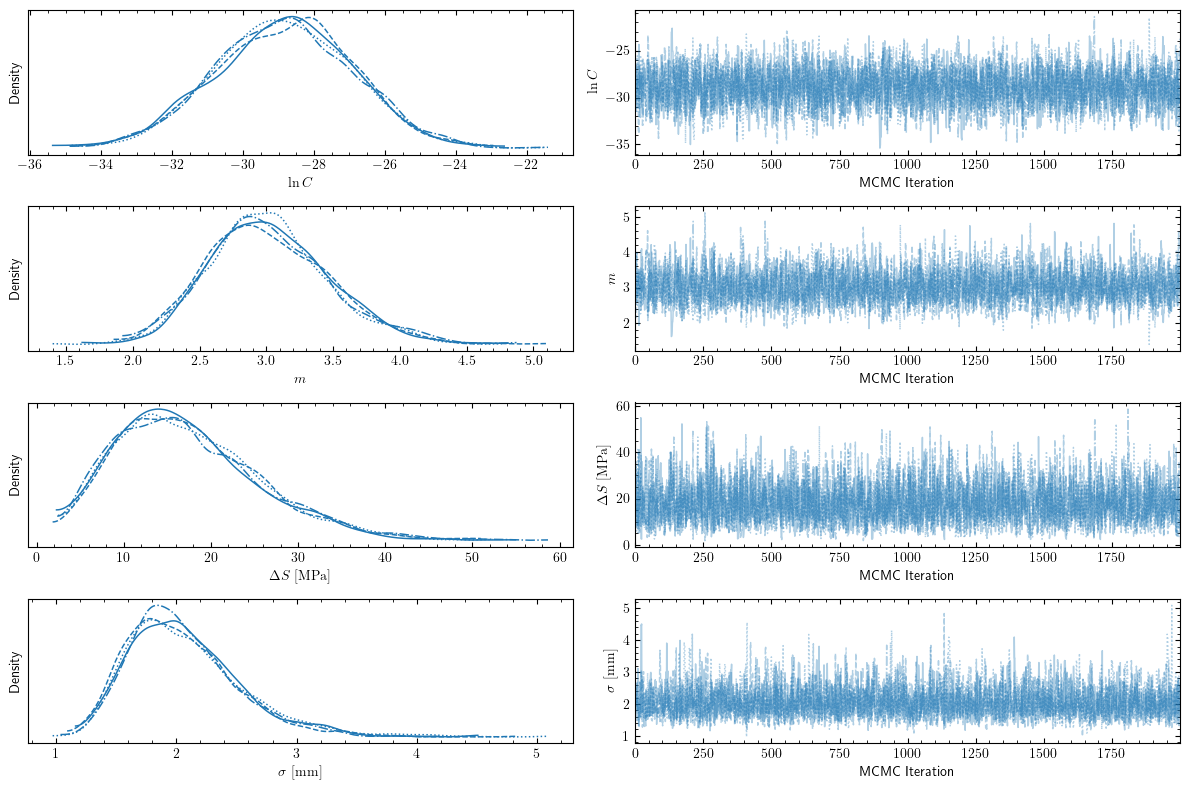

In [60]:
# Visualize posterior distributions
var_names = ["logc", "m", "ds", "noise_std"]
plot_var_names= [r"$\ln C$",  r"$m$", r"$\Delta S \ \mathrm{[MPa]}$", r"$\sigma \ \mathrm{[mm]}$"]
plot_posterior_trace(results['samples'], var_names=var_names, plot_var_names=plot_var_names,
                      save_fig_name="post_trace_stl_classic_c1_12.svg", compact='True')

In [61]:
# Define the true values (for demonstration)
true_values = {
    "logc": true_logc,
    "m": true_m,
    "ds": true_ds,
    "noise_std": 1.5  # Noise used in generating observations
}

# Define nice display names for plotting
plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}

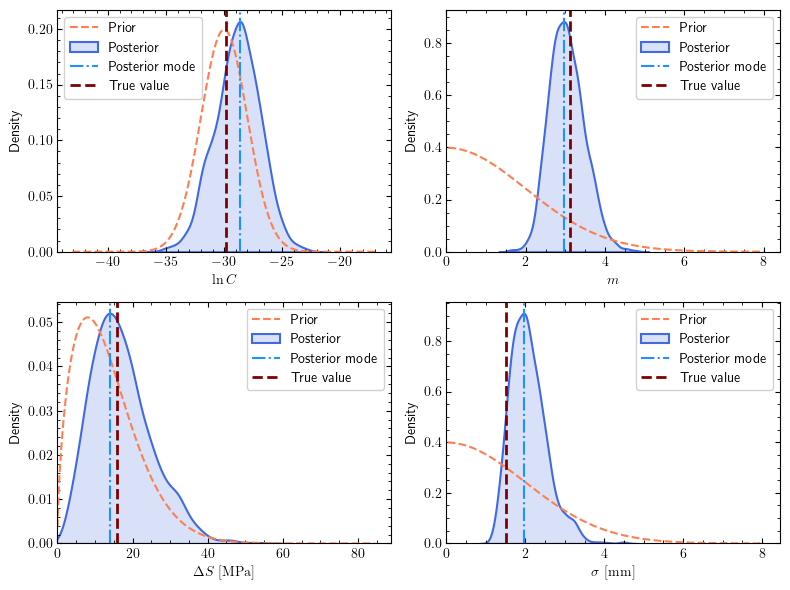

In [62]:
# Extract posterior samples
posterior_samples = results['samples']
# Create the comparison plot with extended prior range for better visualization
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=posterior_samples,
    prior_dists=priors,
    true_values=true_values,
    var_names=var_names,
    plot_var_names=plot_labels,
    figsize=(8.0, 6.0),
    n_cols=2,
    point_estimate='mode',
    save_fig_name="prior_post_comp_stl_classic_c1_12.svg",
    use_first_chain_only=True,
    prior_range_extension=1.0
)

In [92]:
# Generate predictions using the preferred posterior predictive sampling method
# Note: The legacy generate_predictions method is deprecated
posterior_predictive_output = model.generate_posterior_predictive(
    num_samples=1000,
    component_idx=component_idx,
    navg=2.8e6,
    random_seed=42
)

In [93]:
# Use the new visualization function to plot posterior predictive samples
from src.visualisation import plot_posterior_predictive_stl

# Get times and data for plotting
true_times = trajectories['times'][component_idx]
true_crack_lengths = trajectories['crack_lengths'][component_idx]
observed_times = obs['times'][component_idx]
observed_crack_lengths = obs['noisy_crack_lengths'][component_idx]


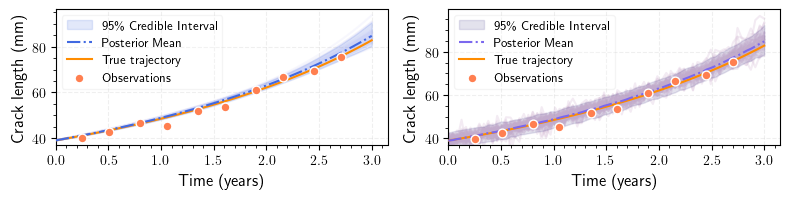

In [ ]:
# Plot the predicted crack lengths (default behavior)
fig1, ax1, stats = plot_posterior_predictive_stl(
    posterior_predictions=posterior_predictive_output,
    true_times=true_times,
    true_crack_lengths=true_crack_lengths,
    observed_times=observed_times,
    observed_crack_lengths=observed_crack_lengths,
    max_samples=50,
    figsize=(8.0, 2.1),
    save_fig_name="post_pred_stl_classic_c3_10.svg",
)


## Using the Output Utilities Module for Parameter Comparison

We'll use the new `output_utils` module to calculate error metrics and create formatted comparison tables for our Bayesian inference results across different components.

In [95]:
import warnings
warnings.filterwarnings("ignore")

In [96]:
# Now let's run the model on all three components to compare performance
component_results = []

for i in range(3):
    print(f"\nRunning inference for component {i+1}...")
    
    # Extract true parameters
    true_logc = np.log(trajectories['paris_c'][i])
    true_m = trajectories['paris_m'][i]
    true_a0 = trajectories['initial_crack_length'][i]
    
    print(f"True parameters for component {i + 1}:")
    print(f"logC: {true_logc:.4f}")
    print(f"m: {true_m:.4f}")
    print(f"a0: {true_a0:.4f}")
    
    # Create a new model for each component
    # For efficiency, use fewer samples for this comparison
    model = STLBayesianModel(priors=priors, crack_growth_data=obs)
    results = model.run_inference(
        component_idx=i,
        num_warmup=2000,
        num_samples=2000,
        num_chains=2,
        progress_bar=True
    )
    
    # Store results
    component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'ds': controlled_data['stress_ranges'][i],
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': results['samples']['logc'],
            'm': results['samples']['m'],
            'ds': results['samples']['ds'],
            'noise_std': results['samples']
            ['noise_std'],
        }
    })



Running inference for component 1...
True parameters for component 1:
logC: -29.8000
m: 3.1200
a0: 41.0000


sample: 100%|██████████| 4000/4000 [00:00<00:00, 7163.96it/s, 127 steps of size 1.67e-02. acc. prob=0.94]



Running inference for component 2...
True parameters for component 2:
logC: -29.8000
m: 3.1200
a0: 37.0000


sample: 100%|██████████| 4000/4000 [00:01<00:00, 3556.53it/s, 1023 steps of size 5.62e-03. acc. prob=0.97]



Running inference for component 3...
True parameters for component 3:
logC: -29.8000
m: 3.1200
a0: 39.0000


sample: 100%|██████████| 4000/4000 [00:01<00:00, 2289.60it/s, 511 steps of size 5.11e-03. acc. prob=0.96] 


In [97]:
from src.output_utils import create_comparison_summary, save_comparison_summary

In [98]:
# Use our new output_utils module to create the comparison table
comparison_df = create_comparison_summary(component_results)
display(comparison_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
ds_target,16.0,22.0,19.0
ds_mean,15.817923,21.990589,18.213606
ds_std,8.823447,9.410543,8.551555
ds_hdi_lower,2.235932,5.351747,3.002091
ds_hdi_upper,33.535904,40.945099,34.774002
ds_rmse,8.825326,9.410548,8.587636
ds_mape,43.356354,34.201028,36.276879
logc_target,-29.8,-29.8,-29.8
logc_mean,-29.299051,-27.422523,-28.696012


In [63]:
save_comparison_summary(comparison_df, "stl_comparison_classic", "excel")

'/Users/nikos/Library/CloudStorage/OneDrive-Personal/Research (NTUA)/Postdoctoral Research/Stochastic Crack Growth Monitoring/Code/outputs/stl_comparison_classic.xlsx'

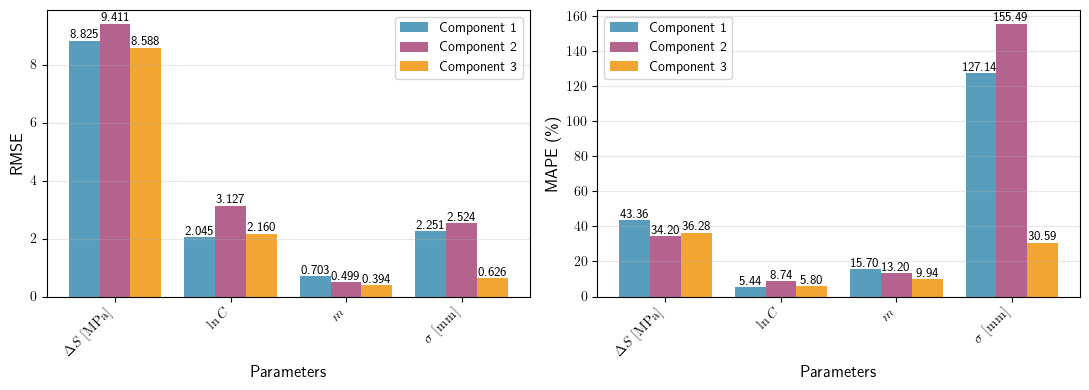

In [99]:
from src.visualisation import plot_performance_metrics
# Plot performance metrics for the comparison
fig, ax = plot_performance_metrics(summary_df=comparison_df,
                                   parameter_labels=plot_labels,
                                   figsize=(11., 4.0),
                                   colors=['#2E86AB', '#A23B72', '#F18F01'],
                                   save_fig_name="perf_comp_stl_classic_sparse.svg")

## Multi-Task Learning (MTL) with Hierarchical Bayesian Modelling

So far, we have applied **Single-Task Learning (STL)** where each component is modelled independently. Whilst this approach works, it doesn't take advantage of the fact that our three components share the same underlying Paris law parameters (`logC = -29.8`, `m = 3.12`).

### The Problem with Independent Modelling

When we model each component separately:
- Each component's inference is based only on its own limited observations
- We don't share information between components that might have similar physics
- This can lead to higher uncertainty and potentially biased estimates, especially with limited data

### The Multi-Task Learning Solution

**Multi-Task Learning (MTL)** treats the inference problem as learning multiple related tasks simultaneously. In our crack growth context:

- **Tasks**: Each component represents a different "task"
- **Shared Parameters**: Paris law parameters (C, m) and observation noise that are common across all components
- **Component-Specific Parameters**: Stress ranges that vary by component and must be inferred

### Hierarchical Bayesian Framework

We implement MTL using a **hierarchical Bayesian model** with two levels:

1. **Fixed Effects (Population Level)**:
   - Paris law parameters `logC` and `m` are shared across all components (material properties)
   - Observation noise `σ` is shared across all components (measurement system properties)

2. **Random Effects (Component Level)**:
   - Stress ranges `Δσᵢ` vary by component and are inferred from the crack growth data
   - These represent unknown or uncertain loading conditions for each component

3. **Known Constants (Task-Specific)**:
   - Initial crack lengths `a₀ᵢ` are measured at baseline for each component

### Why This Structure Makes Sense

This hierarchical structure reflects realistic engineering scenarios:

- **Material properties** (`logC`, `m`) should be consistent across components made of the same material
- **Measurement precision** (`σ`) should be consistent when using the same monitoring equipment
- **Initial crack sizes** (`a₀ᵢ`) can be measured directly at the start of monitoring
- **Stress conditions** (`Δσᵢ`) are often unknown or highly uncertain in practice, making their inference from crack growth data extremely valuable

### Expected Benefits

By pooling information across components, MTL should:
- **Reduce uncertainty** in estimates of shared material properties
- **Improve accuracy** especially when individual components have limited data
- **Enable stress inference** from crack growth observations, providing valuable insights into actual loading conditions
- **Provide better predictions** by leveraging the full dataset
- **Enable knowledge transfer** from data-rich to data-poor components

Let's implement this approach and compare it with our STL results!

### Implementing the MTL Bayesian Model

Now let's implement the hierarchical Bayesian model that jointly learns from all components simultaneously. This model will treat the Paris law parameters (`logC`, `m`) and observation noise (`σ`) as **population-level (fixed effects)** parameters shared across all components, while inferring component-specific **stress ranges** (`Δσᵢ`) as **random effects**.

In [37]:
# Define priors for Multi-Task Learning (MTL) with conditional hyperpriors
import numpyro.distributions as dist

# MTL priors for shared parameters (fixed effects)
mtl_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = {
    "weibull_concentration": dist.Gamma(10.0, 1.0),  # Shape parameter for ds distribution
    "weibull_scale": dist.Gamma(15.0, 1.0)           # Scale parameter for ds distribution
}

In [38]:
# Create MTL Bayesian model with conditional hyperpriors
from src.bayesian_models import MTLBayesianModel

# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
mtl_model = MTLBayesianModel(
    priors=mtl_priors,                    # Fixed effects priors
    crack_growth_data=obs, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

print("MTL Model Configuration:")
print(f"- Number of components: {len(obs['times'])}")
print(f"- Shared parameters: {list(mtl_priors.keys())}")
print(f"- Component-specific parameters: stress ranges (ds)")
print(f"- Hyperprior mode: {'Hierarchical' if hyperpriors else 'Simple'}")
print(f"- Observations per component: {[len(times) for times in obs['times']]}")

MTL Model Configuration:
- Number of components: 3
- Shared parameters: ['logc', 'm', 'noise_std']
- Component-specific parameters: stress ranges (ds)
- Hyperprior mode: Hierarchical
- Observations per component: [12, 12, 12]


In [156]:
# Run hierarchical MTL inference
print("Running hierarchical Multi-Task Learning inference...")
print("This jointly learns from all components while sharing information about:")
print("- Material properties (logC, m)")
print("- Measurement system (noise_std)")
print("- Stress range population distribution (via hyperpriors)")

mtl_results = mtl_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)

print("\nInference completed!")
print(f"Inferred shared parameters:")
print(f"  logC: {mtl_results['summary']['mean']['logc']:.4f} ± {mtl_results['summary']['sd']['logc']:.4f} (true: {true_logc:.4f})")
print(f"  m: {mtl_results['summary']['mean']['m']:.4f} ± {mtl_results['summary']['sd']['m']:.4f} (true: {true_m:.4f})")
print(f"  noise_std: {mtl_results['summary']['mean']['noise_std']:.4f} ± {mtl_results['summary']['sd']['noise_std']:.4f} (true: 1.5 mm)")

print(f"\nLearned population distribution parameters:")
print(f"  Weibull concentration: {mtl_results['summary']['mean']['weibull_concentration']:.3f} ± {mtl_results['summary']['sd']['weibull_concentration']:.3f}")
print(f"  Weibull scale: {mtl_results['summary']['mean']['weibull_scale']:.3f} ± {mtl_results['summary']['sd']['weibull_scale']:.3f}")

print(f"\nInferred component stress ranges:")
for i in range(3):
    mean_ds = mtl_results['summary']['mean'][f'ds[{i}]']
    sd_ds = mtl_results['summary']['sd'][f'ds[{i}]']
    true_ds = controlled_data['stress_ranges'][i]
    print(f"  Component {i+1}: {mean_ds:.2f} ± {sd_ds:.2f} MPa (true: {true_ds:.1f} MPa)")

Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (via hyperpriors)


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1439.43it/s, 39 steps of size 4.29e-03. acc. prob=0.96]  
arviz - WARNING - Array contains NaN-value.



Inference completed!
Inferred shared parameters:
  logC: -28.9390 ± 1.5530 (true: -29.8000)
  m: 3.4170 ± 0.3180 (true: 3.1200)
  noise_std: 1.9590 ± 0.4240 (true: 1.5 mm)

Learned population distribution parameters:
  Weibull concentration: 10.685 ± 3.023
  Weibull scale: 12.697 ± 3.008

Inferred component stress ranges:
  Component 1: 8.56 ± 2.41 MPa (true: 16.0 MPa)
  Component 2: 11.40 ± 3.28 MPa (true: 22.0 MPa)
  Component 3: 9.84 ± 2.78 MPa (true: 19.0 MPa)


In [157]:
# Print full posterior summary
az_post = mtl_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:", az_post)

arviz - WARNING - Array contains NaN-value.
arviz - WARNING - Array contains NaN-value.


                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  \
ds[0]                            8.563  2.410   4.268   12.948      0.054   
ds[1]                           11.399  3.283   5.453   17.312      0.073   
ds[2]                            9.837  2.777   5.199   15.214      0.062   
logc                           -28.939  1.553 -32.167  -26.255      0.029   
m                                3.417  0.318   2.815    4.012      0.006   
noise_std                        1.959  0.424   1.248    2.729      0.007   
predicted_crack_lengths[0, 0]   50.178  0.720  48.805   51.517      0.008   
predicted_crack_lengths[0, 1]   56.561  1.743  53.291   59.879      0.020   
predicted_crack_lengths[0, 2]      NaN    NaN     NaN      NaN        NaN   
predicted_crack_lengths[0, 3]      NaN    NaN     NaN      NaN        NaN   
predicted_crack_lengths[0, 4]      NaN    NaN     NaN      NaN        NaN   
predicted_crack_lengths[0, 5]      NaN    NaN     NaN      NaN        NaN   

In [158]:
mtl_model.check_rhat()

arviz - WARNING - Array contains NaN-value.


R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
ds[0]                    : 1.0040 ✓ 
ds[1]                    : 1.0030 ✓ 
ds[2]                    : 1.0040 ✓ 
logc                     : 1.0030 ✓ 
m                        : 1.0020 ✓ 
noise_std                : 1.0010 ✓ 
predicted_crack_lengths[0, 0]: 1.0010 ✓ 
predicted_crack_lengths[0, 1]: 1.0010 ✓ 
predicted_crack_lengths[0, 2]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 3]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 4]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 5]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 6]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 7]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 8]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[1, 0]: 1.0020 ✓ 
predicted_crack_lengths[1, 1]: 1.0020 ✓ 
predicted_crack_lengths[1, 2]: 1.0010 ✓ 
predic

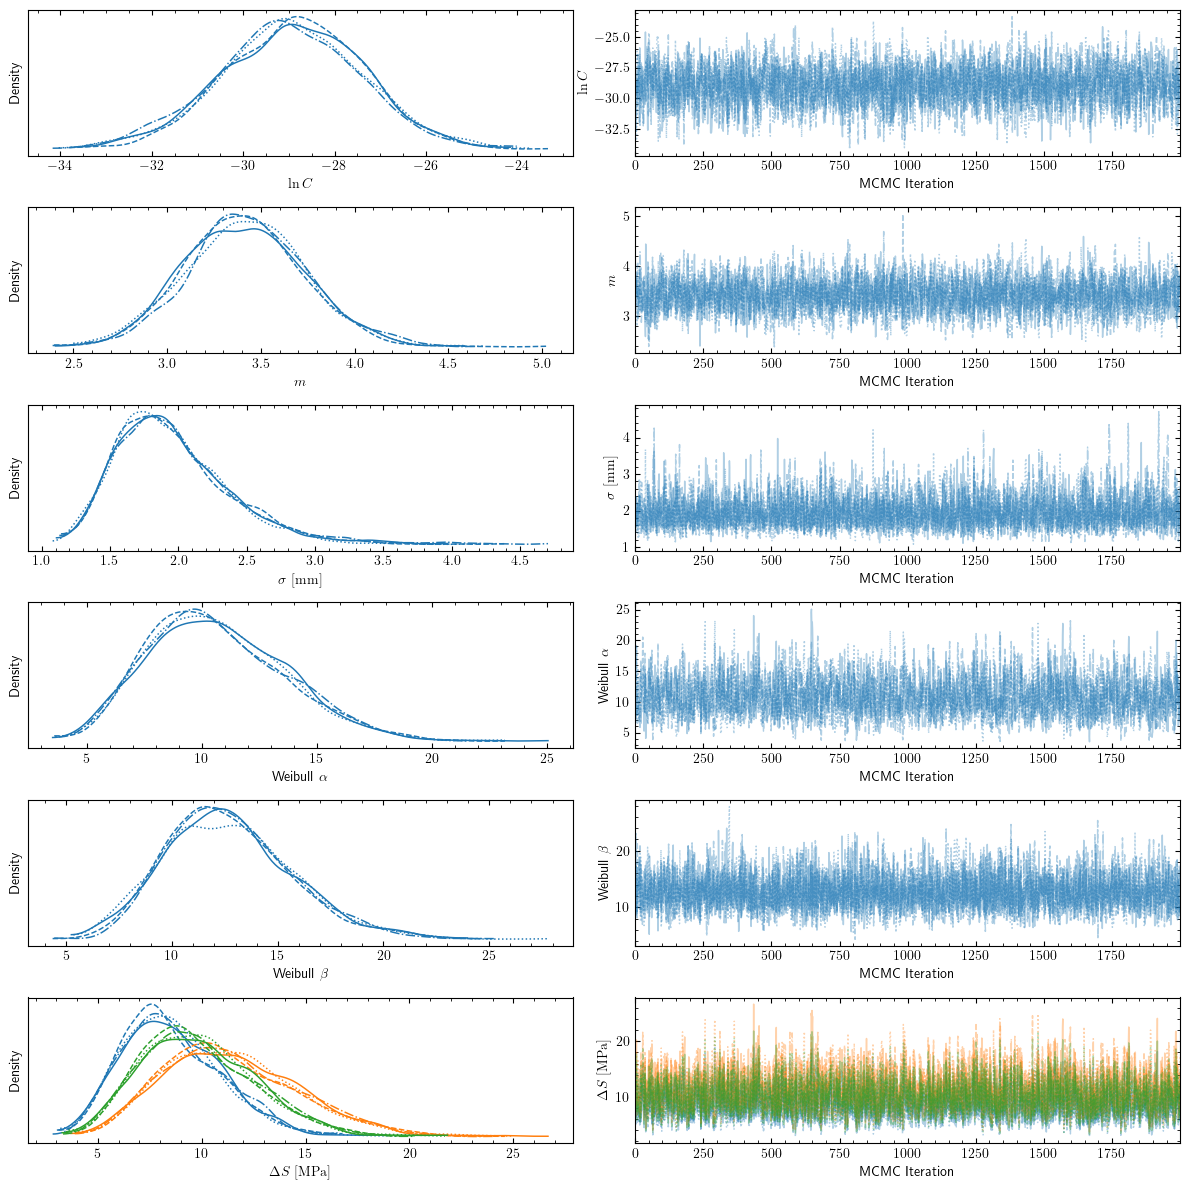

In [159]:
# Visualize MTL posterior traces to check convergence
from src.visualisation import plot_posterior_trace

# Define variables to plot - include shared parameters and hyperpriors
mtl_var_names = ["logc", "m", "noise_std", "weibull_concentration", "weibull_scale", "ds"]
mtl_plot_labels = [
    r"$\ln C$", 
    r"$m$", 
    r"$\sigma \ \mathrm{[mm]}$",
    r"Weibull $\alpha$",
    r"Weibull $\beta$",
    r"$\Delta S \ \mathrm{[MPa]}$"
]

# Create trace plots for MTL parameters
plot_posterior_trace(
    mtl_results['samples'], 
    var_names=mtl_var_names, 
    plot_var_names=mtl_plot_labels,
    compact=True,
    save_fig_name="post_trace_mtl_fh_classic_sparse.pdf")

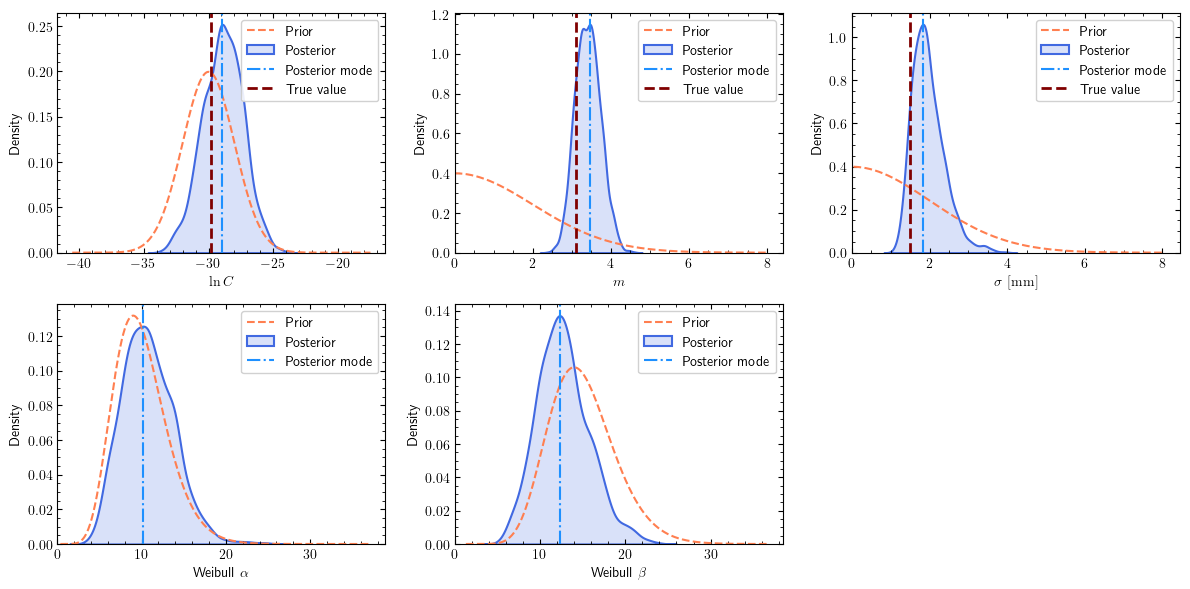

In [160]:
# Compare MTL priors vs posteriors with true values for ALL parameters
from src.visualisation import plot_prior_posterior_comparison

# First, let's create extended priors that include all parameters in the MTL model
# We need to add component-specific priors for stress ranges
mtl_extended_priors = mtl_priors.copy()  # Start with population-level priors
# Also add the hyperpriors to the extended priors dictionary
mtl_extended_priors.update(hyperpriors)

# Define true values for ALL MTL parameters
mtl_extended_true_values = {
    # Population-level parameters (shared across components)
    "logc": true_logc,  # True shared logC
    "m": true_m,        # True shared m  
    "noise_std": 1.5,   # True observation noise
    
    # Component-specific stress ranges (true values)
    "ds[0]": controlled_data['stress_ranges'][0],  # Component 1: 16.0 MPa
    "ds[1]": controlled_data['stress_ranges'][1],  # Component 2: 22.0 MPa
    "ds[2]": controlled_data['stress_ranges'][2],  # Component 3: 19.0 MPa
    
    # Hyperpriors don't have "true" values since they're learned from data
    # We'll omit them from true_values so they don't get vertical lines
}

# Create comprehensive variable list for all MTL parameters
all_mtl_vars = [
    # Population-level (shared) parameters
    "logc", "m", "noise_std",
    # Hyperprior parameters  
    "weibull_concentration", "weibull_scale",
]

# Create display labels for all parameters
all_mtl_labels = {
    # Population-level parameters
    "logc": r"$\ln C$",
    "m": r"$m$", 
    "noise_std": r"$\sigma \ \mathrm{[mm]}$",
    
    # Hyperprior parameters
    "weibull_concentration": r"Weibull $\alpha$",
    "weibull_scale": r"Weibull $\beta$",
}

# Create the comprehensive comparison plot
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=mtl_results['samples'],
    prior_dists=mtl_extended_priors,
    true_values=mtl_extended_true_values,
    var_names=all_mtl_vars,
    plot_var_names=all_mtl_labels,
    figsize=(12.0, 6.0),  # Larger figure to accommodate all parameters
    n_cols=3,              # 3 columns for better layout
    point_estimate='mode',
    save_fig_name="prior_post_comp_mtl_fh_classic_sparse.pdf",
    use_first_chain_only=True,
    prior_range_extension=1.0
)

True stress ranges (targets):
  Component 1: 16.0 MPa
  Component 2: 22.0 MPa
  Component 3: 19.0 MPa


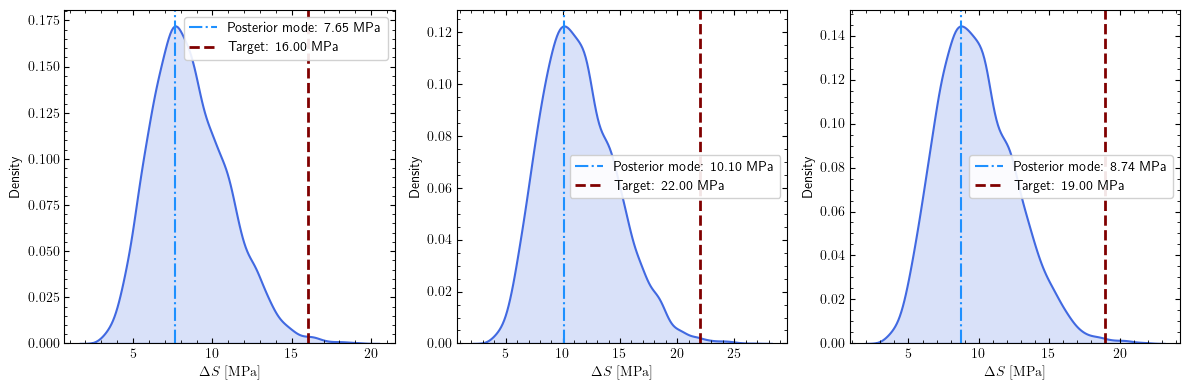

In [161]:
# Demonstrate the new random effects visualization function
from src.visualisation import plot_random_effect_posteriors

# Define targets for the random effects (stress ranges)
# These are the true stress ranges used in our controlled experiment
stress_targets = {
    "ds[0]": controlled_data['stress_ranges'][0],  # Component 1: 16.0 MPa
    "ds[1]": controlled_data['stress_ranges'][1],  # Component 2: 22.0 MPa  
    "ds[2]": controlled_data['stress_ranges'][2],  # Component 3: 19.0 MPa
}

print("True stress ranges (targets):")
for key, value in stress_targets.items():
    component_num = key.split('[')[1].split(']')[0]
    print(f"  Component {int(component_num)+1}: {value:.1f} MPa")

# Create the random effects posterior plot
fig, axes = plot_random_effect_posteriors(
    posterior_samples=mtl_results['samples'],
    targets=stress_targets,
    param_name="ds",
    plot_var_name=r"$\Delta S \ \mathrm{[MPa]}$",
    figsize=(12.0, 4.0),
    n_cols=3,
    point_estimate='mode',
    save_fig_name="random_effects_mtl_fh_classic_sparse.pdf"
)

Processing component 1...
Processing component 2...
Processing component 3...


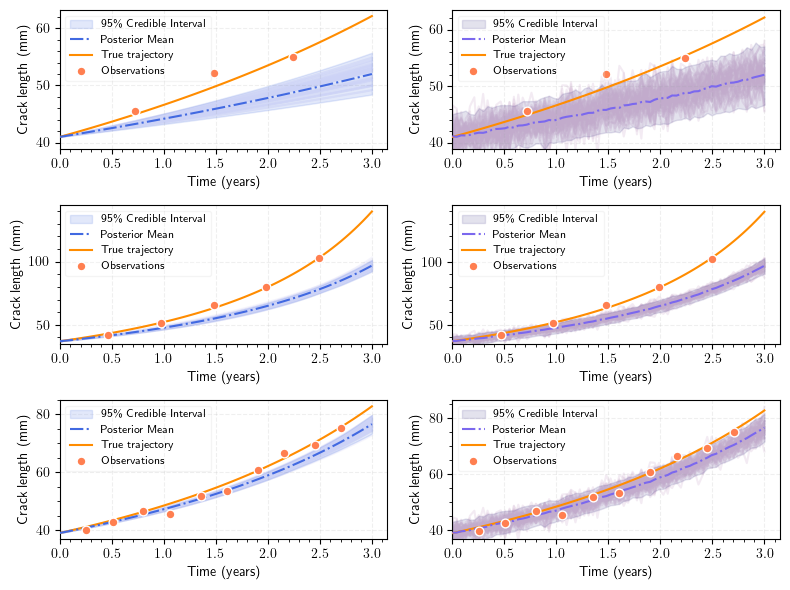

In [163]:
# Demonstration of the refactored MTL visualization function
# The function now takes pre-computed posterior predictions as input
# instead of generating them internally from the model

from src.visualisation import plot_posterior_predictive_mtl

# Step 1: Generate posterior predictions for all components
# Using the MTL model and controlled data from earlier in the notebook

# Generate predictions for each component separately
posterior_predictions_list = []
true_times_list = []
true_crack_lengths_list = []
observed_times_list = []
observed_crack_lengths_list = []

n_components = len(obs['times'])

for i in range(n_components):
    print(f"Processing component {i+1}...")
    
    # Generate posterior predictions for this component
    predictions = mtl_model.generate_posterior_predictive(
        component_idx=i,  # Component index to predict
        num_samples=500,  # Reduced for demo speed
        Y=1.12,           # Geometry factor
        navg=2.8e6,       # Average cycles per year
        random_seed=42
    )
    
    posterior_predictions_list.append(predictions)
    
    # Extract the true and observed data for this component
    # Use the correct data structure access patterns
    true_times_list.append(controlled_data['times'])
    true_crack_lengths_list.append(controlled_data['crack_lengths'][i])
    observed_times_list.append(obs['times'][i])
    observed_crack_lengths_list.append(obs['noisy_crack_lengths'][i])


# Step 2: Use the refactored visualization function
# This demonstrates the new interface pattern that separates prediction generation from visualization

# Plot predictions (showing model predictions vs true trajectories)
fig1, ax1, stats1 = plot_posterior_predictive_mtl(
    posterior_predictions_list=posterior_predictions_list,
    true_times_list=true_times_list,
    true_crack_lengths_list=true_crack_lengths_list,
    observed_times_list=observed_times_list,
    observed_crack_lengths_list=observed_crack_lengths_list,
    max_samples=50,
    figsize=(8., 6.),
    save_fig_name="post_pred_mtl_fh_classic_sparse.pdf"
)

Let's try to print a summary of results in table and graphic format.

In [164]:
# Store results
mtl_component_results = []

for i in range(mtl_results['samples']['ds'].shape[2]):
    mtl_component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'ds': controlled_data['stress_ranges'][i],
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': mtl_results['samples']['logc'],
            'm': mtl_results['samples']['m'],
            'ds': mtl_results['samples']['ds'][:, :, i],
            'noise_std': mtl_results['samples']['noise_std'],
        }
        })

In [165]:
mtl_summary_df = create_comparison_summary(mtl_component_results)
display(mtl_summary_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
ds_target,16.0,22.0,19.0
ds_mean,8.562634,11.39873,9.836637
ds_std,2.41018,3.282414,2.77636
ds_hdi_lower,4.330589,5.75259,5.162976
ds_hdi_upper,13.34939,18.108101,15.569849
ds_rmse,7.818145,11.0978,9.574728
ds_mape,46.552692,48.240366,48.271893
logc_target,-29.8,-29.8,-29.8
logc_mean,-28.939449,-28.939449,-28.939449


In [ ]:
mtl_plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}
fig, ax = plot_performance_metrics(summary_df=mtl_summary_df,
                        parameter_labels=mtl_plot_labels,
                        figsize=(11., 4.0),
                        colors=['#2E86AB', '#A23B72', '#F18F01'],
                        save_fig_name="perf_comp_mtl_fh_classic_sparse.pdf")

### MTL assuming i.i.d. random effects

In [102]:
# Define priors for Multi-Task Learning (MTL) without conditional hyperpriors
import numpyro.distributions as dist

# MTL priors for shared parameters (fixed effects)
mtl_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = None

In [103]:
from src.bayesian_models import MTLBayesianModel
# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
mtl_iid_model = MTLBayesianModel(
    priors=mtl_priors,                    # Fixed effects priors
    crack_growth_data=obs, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

print("MTL Model Configuration:")
print(f"- Number of components: {len(obs['times'])}")
print(f"- Shared parameters: {list(mtl_priors.keys())}")
print(f"- Component-specific parameters: stress ranges (ds)")
print(f"- Hyperprior mode: {'Hierarchical' if hyperpriors else 'Simple'}")
print(f"- Observations per component: {[len(times) for times in obs['times']]}")

MTL Model Configuration:
- Number of components: 3
- Shared parameters: ['logc', 'm', 'noise_std', 'ds']
- Component-specific parameters: stress ranges (ds)
- Hyperprior mode: Simple
- Observations per component: [3, 5, 10]


In [104]:
# Run hierarchical MTL inference
print("Running hierarchical Multi-Task Learning inference...")
print("This jointly learns from all components while sharing information about:")
print("- Material properties (logC, m)")
print("- Measurement system (noise_std)")
print("- Stress range population distribution (without hyperpriors)")

mtl_results = mtl_iid_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)

print("\nInference completed!")
print(f"Inferred shared parameters:")
print(f"  logC: {mtl_results['summary']['mean']['logc']:.4f} ± {mtl_results['summary']['sd']['logc']:.4f} (true: {true_logc:.4f})")
print(f"  m: {mtl_results['summary']['mean']['m']:.4f} ± {mtl_results['summary']['sd']['m']:.4f} (true: {true_m:.4f})")
print(f"  noise_std: {mtl_results['summary']['mean']['noise_std']:.4f} ± {mtl_results['summary']['sd']['noise_std']:.4f} (true: 1.5 mm)")

print(f"\nInferred component stress ranges:")
for i in range(3):
    mean_ds = mtl_results['summary']['mean'][f'ds[{i}]']
    sd_ds = mtl_results['summary']['sd'][f'ds[{i}]']
    true_ds = controlled_data['stress_ranges'][i]
    print(f"  Component {i+1}: {mean_ds:.2f} ± {sd_ds:.2f} MPa (true: {true_ds:.1f} MPa)")

Running hierarchical Multi-Task Learning inference...
This jointly learns from all components while sharing information about:
- Material properties (logC, m)
- Measurement system (noise_std)
- Stress range population distribution (without hyperpriors)


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1932.32it/s, 511 steps of size 4.86e-03. acc. prob=0.93] 
arviz - WARNING - Array contains NaN-value.



Inference completed!
Inferred shared parameters:
  logC: -28.7890 ± 1.6500 (true: -29.8000)
  m: 3.0980 ± 0.3150 (true: 3.1200)
  noise_std: 1.9220 ± 0.4070 (true: 1.5 mm)

Inferred component stress ranges:
  Component 1: 13.11 ± 4.15 MPa (true: 16.0 MPa)
  Component 2: 18.65 ± 6.11 MPa (true: 22.0 MPa)
  Component 3: 15.73 ± 5.03 MPa (true: 19.0 MPa)


In [42]:
mtl_iid_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:")

                                   mean     sd   hdi_3%  hdi_97%  mcse_mean  \
ds[0]                            12.470  3.828    5.664   19.683      0.118   
ds[1]                            17.483  5.411    7.951   27.753      0.165   
ds[2]                            15.108  4.652    6.881   23.842      0.142   
logc                            -29.328  1.176  -31.507  -27.116      0.036   
m                                 3.221  0.143    2.939    3.479      0.003   
noise_std                         1.437  0.197    1.092    1.808      0.004   
predicted_crack_lengths[0, 0]    43.267  0.045   43.182   43.352      0.001   
predicted_crack_lengths[0, 1]    44.492  0.094   44.315   44.670      0.001   
predicted_crack_lengths[0, 2]    45.774  0.147   45.496   46.049      0.002   
predicted_crack_lengths[0, 3]    47.116  0.204   46.728   47.499      0.002   
predicted_crack_lengths[0, 4]    48.523  0.266   48.006   49.012      0.003   
predicted_crack_lengths[0, 5]    49.997  0.334   49.

In [105]:
mtl_iid_model.check_rhat()

arviz - WARNING - Array contains NaN-value.


R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
ds[0]                    : 1.0020 ✓ 
ds[1]                    : 1.0020 ✓ 
ds[2]                    : 1.0020 ✓ 
logc                     : 1.0020 ✓ 
m                        : 1.0020 ✓ 
noise_std                : 1.0010 ✓ 
predicted_crack_lengths[0, 0]: 1.0010 ✓ 
predicted_crack_lengths[0, 1]: 1.0010 ✓ 
predicted_crack_lengths[0, 2]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 3]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 4]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 5]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 6]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 7]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[0, 8]: NaN    N/A (constant/deterministic)
predicted_crack_lengths[1, 0]: 1.0010 ✓ 
predicted_crack_lengths[1, 1]: 1.0010 ✓ 
predicted_crack_lengths[1, 2]: 1.0000 ✓ 
predic

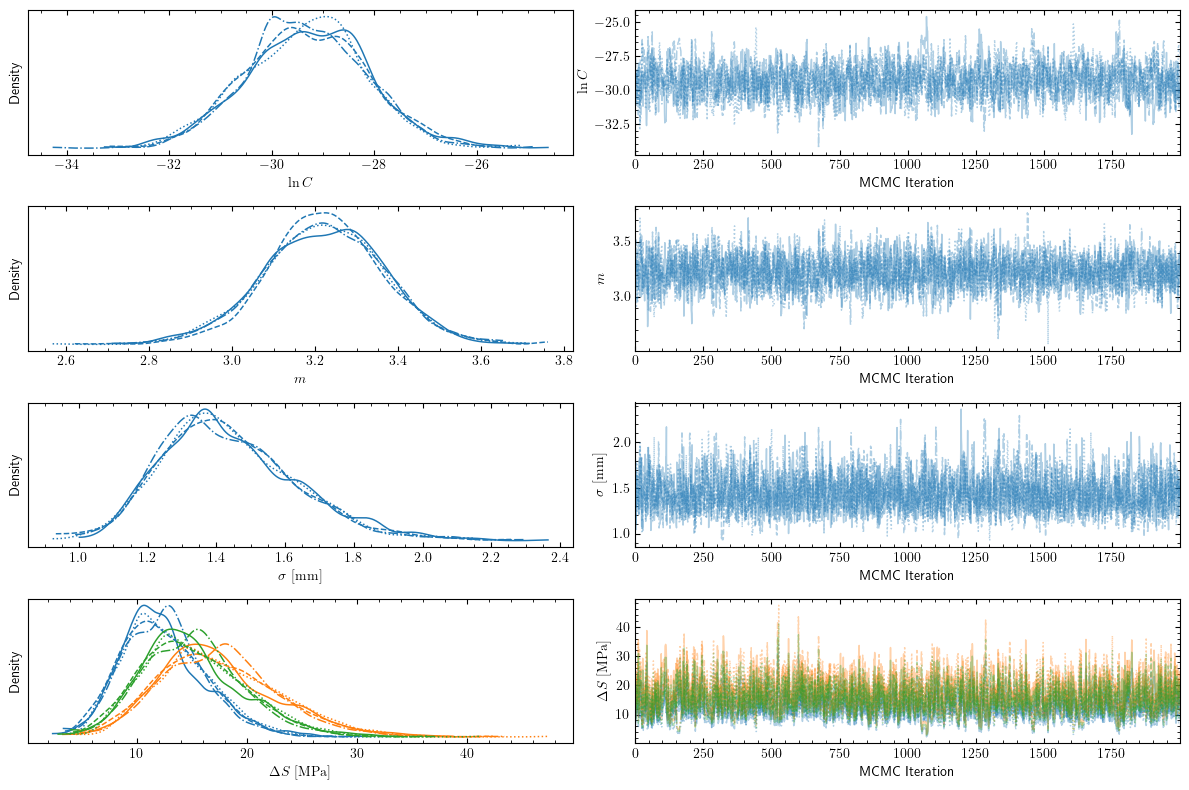

In [44]:
# Define variables to plot - include shared parameters and hyperpriors
mtl_var_names = ["logc", "m", "noise_std", "ds"]
mtl_plot_labels = [
    r"$\ln C$", 
    r"$m$", 
    r"$\sigma \ \mathrm{[mm]}$",
    r"$\Delta S \ \mathrm{[MPa]}$"
]

# Create trace plots for MTL parameters
plot_posterior_trace(
    mtl_results['samples'], 
    var_names=mtl_var_names, 
    plot_var_names=mtl_plot_labels,
    compact=True,
    save_fig_name="post_trace_mtl_iid_classic_12.svg")

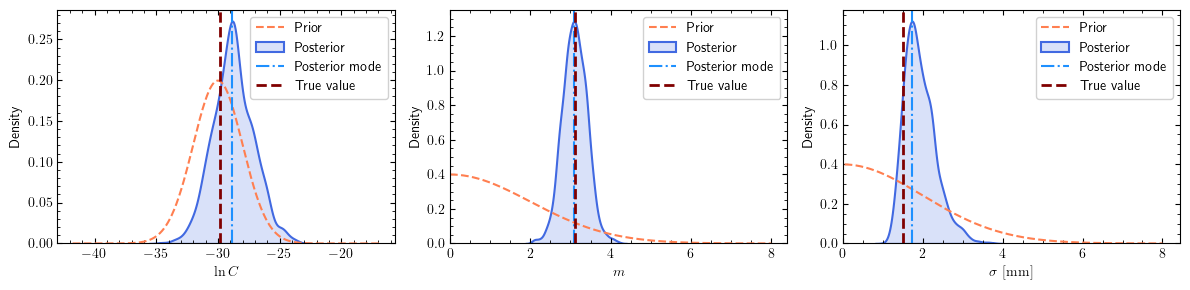

In [112]:
# First, let's create extended priors that include all parameters in the MTL model
# We need to add component-specific priors for stress ranges
mtl_extended_priors = mtl_priors.copy()  # Start with population-level priors

# Define true values for ALL MTL parameters
mtl_extended_true_values = {
    # Population-level parameters (shared across components)
    "logc": true_logc,  # True shared logC
    "m": true_m,        # True shared m  
    "noise_std": 1.5,   # True observation noise
    
    # Component-specific stress ranges (true values)
    "ds[0]": controlled_data['stress_ranges'][0],  # Component 1: 16.0 MPa
    "ds[1]": controlled_data['stress_ranges'][1],  # Component 2: 22.0 MPa
    "ds[2]": controlled_data['stress_ranges'][2],  # Component 3: 19.0 MPa
    
    # Hyperpriors don't have "true" values since they're learned from data
    # We'll omit them from true_values so they don't get vertical lines
}

# Create comprehensive variable list for all MTL parameters
all_mtl_vars = [
    # Population-level (shared) parameters
    "logc", "m", "noise_std",
]

# Create display labels for all parameters
all_mtl_labels = {
    # Population-level parameters
    "logc": r"$\ln C$",
    "m": r"$m$", 
    "noise_std": r"$\sigma \ \mathrm{[mm]}$",
}

# Create the comprehensive comparison plot
fig, axes = plot_prior_posterior_comparison(
    posterior_samples=mtl_results['samples'],
    prior_dists=mtl_extended_priors,
    true_values=mtl_extended_true_values,
    var_names=all_mtl_vars,
    plot_var_names=all_mtl_labels,
    figsize=(12.0, 3.0),  # Larger figure to accommodate all parameters
    n_cols=3,              # 3 columns for better layout
    point_estimate='mode',
    save_fig_name="prior_post_comp_mtl_iid_classic_sparse.svg",
    use_first_chain_only=True,
    prior_range_extension=1.0
)

True stress ranges (targets):
  Component 1: 16.0 MPa
  Component 2: 22.0 MPa
  Component 3: 19.0 MPa

Random Effects Inference Results:
Component 1:
  Inferred: 13.11 ± 4.15 MPa
  True:     16.0 MPa
  Error:    2.89 MPa (18.1%)

Component 2:
  Inferred: 18.65 ± 6.11 MPa
  True:     22.0 MPa
  Error:    3.35 MPa (15.2%)

Component 3:
  Inferred: 15.73 ± 5.03 MPa
  True:     19.0 MPa
  Error:    3.27 MPa (17.2%)



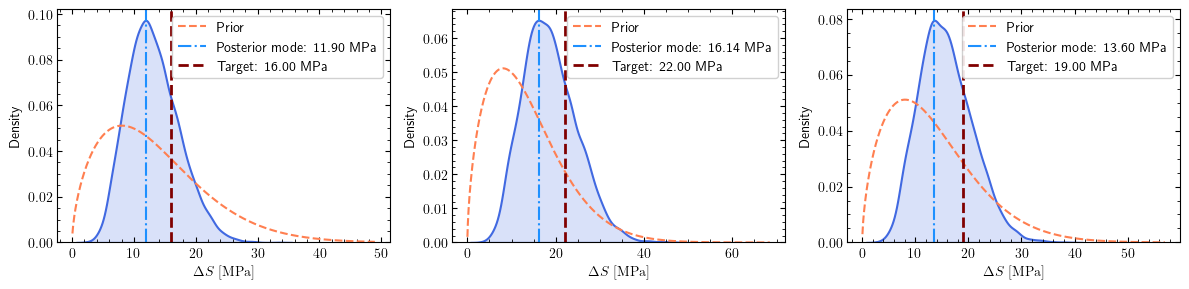

In [113]:
# Define the priors for the random effects (stress ranges)
random_effects_priors = {
    f"ds[{i}]": dist.Weibull(14.9, 1.6) for i in range(3)
}
# Define targets for the random effects (stress ranges)
# These are the true stress ranges used in our controlled experiment
stress_targets = {
    "ds[0]": controlled_data['stress_ranges'][0],  # Component 1: 16.0 MPa
    "ds[1]": controlled_data['stress_ranges'][1],  # Component 2: 22.0 MPa  
    "ds[2]": controlled_data['stress_ranges'][2],  # Component 3: 19.0 MPa
}

print("True stress ranges (targets):")
for key, value in stress_targets.items():
    component_num = key.split('[')[1].split(']')[0]
    print(f"  Component {int(component_num)+1}: {value:.1f} MPa")
from src.visualisation import plot_random_effect_posteriors
# Create the random effects posterior plot
fig, axes = plot_random_effect_posteriors(
    posterior_samples=mtl_results['samples'],
    targets=stress_targets,
    param_name="ds",
    plot_var_name=r"$\Delta S \ \mathrm{[MPa]}$",
    figsize=(12.0, 3.0),
    n_cols=3,
    point_estimate='mode',
    save_fig_name="random_effects_mtl_iid_classic_sparse.svg",
    priors=random_effects_priors
)

# Print some insights about the inference
print("\nRandom Effects Inference Results:")
for i in range(3):
    inferred_mean = mtl_results['summary']['mean'][f'ds[{i}]']
    inferred_sd = mtl_results['summary']['sd'][f'ds[{i}]']
    true_value = controlled_data['stress_ranges'][i]
    error = abs(inferred_mean - true_value)
    relative_error = (error / true_value) * 100
    
    print(f"Component {i+1}:")
    print(f"  Inferred: {inferred_mean:.2f} ± {inferred_sd:.2f} MPa")
    print(f"  True:     {true_value:.1f} MPa")
    print(f"  Error:    {error:.2f} MPa ({relative_error:.1f}%)")
    print()

Processing component 1...
Processing component 2...
Processing component 3...


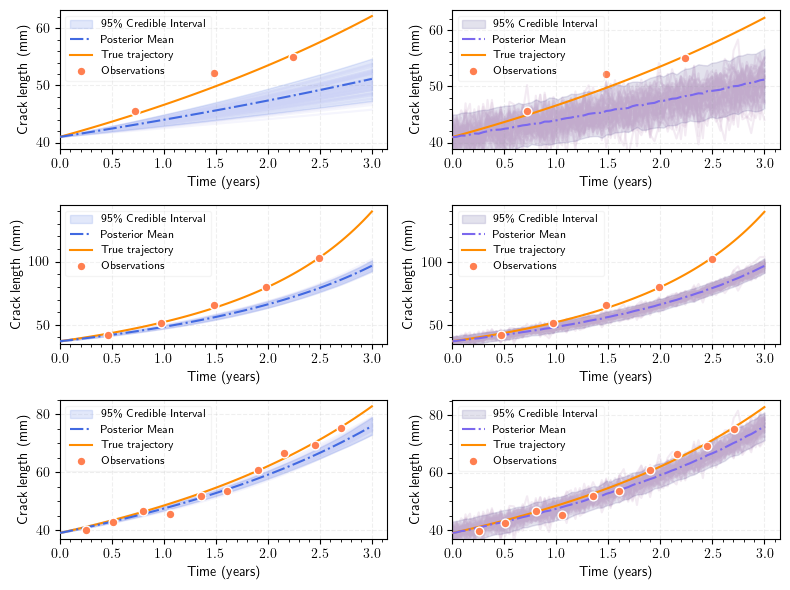

In [106]:
# Step 1: Generate posterior predictions for all components
# Using the MTL model and controlled data from earlier in the notebook

# Generate predictions for each component separately
posterior_predictions_list = []
true_times_list = []
true_crack_lengths_list = []
observed_times_list = []
observed_crack_lengths_list = []

n_components = len(obs['times'])

for i in range(n_components):
    print(f"Processing component {i+1}...")
    
    # Generate posterior predictions for this component
    predictions = mtl_iid_model.generate_posterior_predictive(
        component_idx=i,  # Component index to predict
        num_samples=1000,  # Reduced for demo speed
        Y=1.12,           # Geometry factor
        navg=2.8e6,       # Average cycles per year
        random_seed=42
    )
    
    posterior_predictions_list.append(predictions)
    
    # Extract the true and observed data for this component
    # Use the correct data structure access patterns
    true_times_list.append(controlled_data['times'])
    true_crack_lengths_list.append(controlled_data['crack_lengths'][i])
    observed_times_list.append(obs['times'][i])
    observed_crack_lengths_list.append(obs['noisy_crack_lengths'][i])


# Step 2: Use the refactored visualization function
# This demonstrates the new interface pattern that separates prediction generation from visualization
from src.visualisation import plot_posterior_predictive_mtl
# Plot predictions (showing model predictions vs true trajectories)
fig1, ax1, stats1 = plot_posterior_predictive_mtl(
    posterior_predictions_list=posterior_predictions_list,
    true_times_list=true_times_list,
    true_crack_lengths_list=true_crack_lengths_list,
    observed_times_list=observed_times_list,
    observed_crack_lengths_list=observed_crack_lengths_list,
    max_samples=50,
    figsize=(8., 6.),
    save_fig_name="post_pred_mtl_iid_sparse.svg"
)

In [107]:
# Store results
mtl_iid_component_results = []

for i in range(mtl_results['samples']['ds'].shape[2]):
    mtl_iid_component_results.append({
        'index': i,
        'true_params': {
            'logc': true_logc,
            'm': true_m,
            'a0': true_a0,
            'ds': controlled_data['stress_ranges'][i],
            'noise_std': 1.5  # The true noise std used for generating observations
        },
        'inferred_params': {
            'logc': mtl_results['samples']['logc'],
            'm': mtl_results['samples']['m'],
            'ds': mtl_results['samples']['ds'][:, :, i],
            'noise_std': mtl_results['samples']['noise_std'],
        }
        })

In [108]:
mtl_iid_summary_df = create_comparison_summary(mtl_iid_component_results)
display(mtl_iid_summary_df.T)

,0,1,2
Component,Component 1,Component 2,Component 3
ds_target,16.0,22.0,19.0
ds_mean,13.109101,18.647863,15.726961
ds_std,4.15283,6.109182,5.02731
ds_hdi_lower,5.684147,7.840208,6.925535
ds_hdi_upper,21.332773,30.50894,25.650587
ds_rmse,5.05997,6.968424,5.998886
ds_mape,26.547643,26.396919,26.392378
logc_target,-29.8,-29.8,-29.8
logc_mean,-28.789406,-28.789406,-28.789406


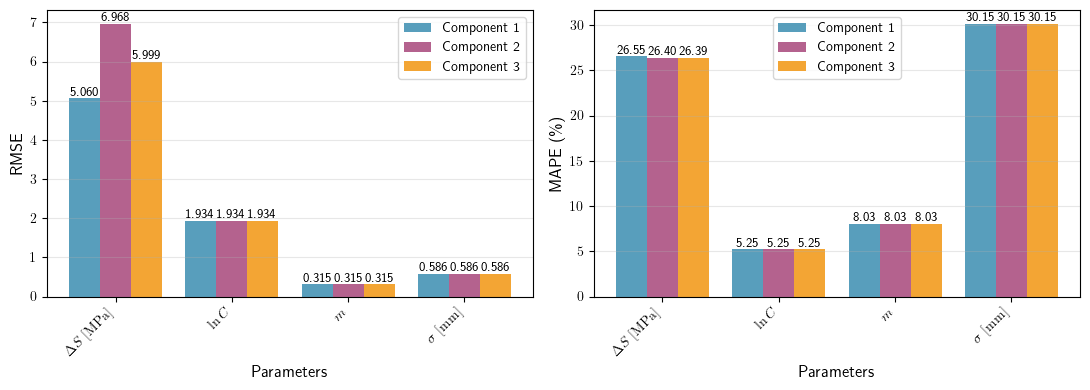

In [ ]:
mtl_plot_labels = {
    "logc": r"$\ln C$",
    "m": r"$m$",
    "ds": r"$\Delta S \ \mathrm{[MPa]}$",
    "noise_std": r"$\sigma \ \mathrm{[mm]}$"
}
fig, ax = plot_performance_metrics(summary_df=mtl_iid_summary_df,
                        parameter_labels=mtl_plot_labels,
                        figsize=(11., 4.),
                        colors=['#2E86AB', '#A23B72', '#F18F01'],
                        save_fig_name="perf_comp_mtl_iid_classic_sparse.svg")

### Hierarchical modelling for uncertainty quantification in cracks growing under variable stress ranges.

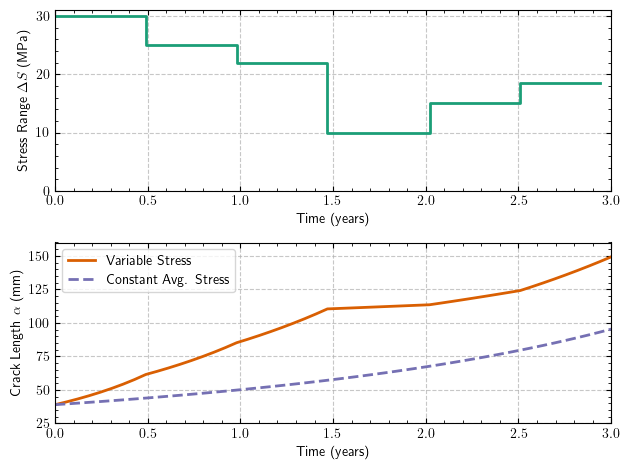

In [73]:
from src.visualisation import plot_variable_stress_comparison

# Define custom stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 22.0),
    (1.5, 2.0, 10.0),
    (2.0, 2.5, 15.0),
    (2.5, 3.0, 18.5)
]

# Use the new visualization function
fig, axs = plot_variable_stress_comparison(
    stress_periods=stress_periods,
    logc=np.log(np.exp(-29.8)),
    m=3.12,
    navg=2.8e6,
    a0=39.0,
    cmap_name='Dark2',
    figsize=(6.4, 4.8),
    save_fig_name=None
)

# Print some interesting statistics about the plot
# print(f"Average stress: {np.mean([s[2] for s in stress_periods]):.2f} MPa")
# print(f"Stress range: {min([s[2] for s in stress_periods]):.1f} - {max([s[2] for s in stress_periods]):.1f} MPa")

In [74]:
from src.crack_growth_models import VariableStressParisErdogan
from src.predictive_models import CrackGrowthPredictor
from src.data_utils import CrackObservationGenerator
import numpy as np

# Your stress periods
stress_periods = [
    (0.0, 0.5, 30.0),
    (0.5, 1.0, 25.0),
    (1.0, 1.5, 22.0),
    (1.5, 2.0, 10.0),
    (2.0, 2.5, 15.0),
    (2.5, 3.0, 18.5)
]

# Define common parameters
common_logc = np.log(np.exp(-29.8))  # logC value
common_m = 3.12                      # m value
common_navg = 2.8e6                  # Average cycles per year 
initial_crack_length = 39.0          # Initial crack length in mm

# Define time discretisation for crack growth simulation
times = np.linspace(0, 3.0, 50)

# Initialise predictor
predictor = CrackGrowthPredictor(model_class=VariableStressParisErdogan)

# Generate crack growth trajectory
var_stress_crack_length = predictor.predict_variable_stress_cracks(
    stress_periods=stress_periods,
    times=times,
    logc=common_logc,
    m=common_m,
    navg=common_navg,
    a0=initial_crack_length
)

In [75]:
var_stress_trajectory = {
    'times': [times],
    'stress_periods': stress_periods,
    'crack_lengths': [var_stress_crack_length],
    'paris_c': common_logc,
    'paris_m': common_m,
    'initial_crack_length': initial_crack_length,
}

In [76]:
obs_generator = CrackObservationGenerator(var_stress_trajectory, random_seed=42)

In [77]:
var_stress_obs = obs_generator.create_observations(strategy='variable_stress', noise_std=2)

In [78]:
from src.visualisation import plot_trajectories_with_observations

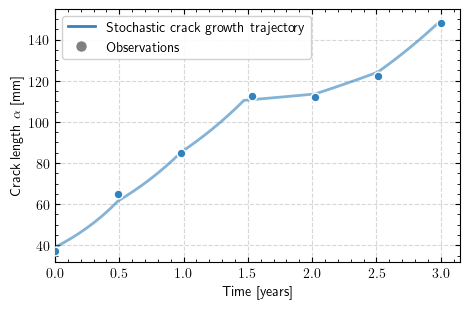

In [79]:
fig, ax = plot_trajectories_with_observations(
    times=var_stress_trajectory['times'],
    crack_lengths=var_stress_trajectory['crack_lengths'],
    obs_times=var_stress_obs['times'],
    obs_lengths=var_stress_obs['noisy_crack_lengths'],
    labels=[f"Stochastic crack growth trajectory"],
    cmap_name='tab20c',
    figsize=(4.8, 3.2),
    traj_alpha=0.6,
    obs_alpha=1.0,
    marker_size=40,
    save_fig_name="var_stress_crack_observations_classic.pdf"
)


#### Implementing hierarchical Bayesian modelling

In [80]:
# Define priors for Multi-Task Learning (MTL) with conditional hyperpriors
import numpyro.distributions as dist

# Priors for shared parameters (fixed effects)
fe_priors = {
    "logc": dist.Normal(-30.0, 2.0),       # Shared Paris law C parameter
    "m": dist.HalfNormal(2.0),            # Shared Paris law exponent
    "noise_std": dist.HalfNormal(2.0)      # Shared observation noise
}

# Optional hyperpriors for stress range distribution (enables hierarchical modeling)
# When provided, stress ranges follow: ds[i] ~ Weibull(concentration, scale)
# When None, stress ranges are i.i.d. with fixed Weibull(14.9, 1.6) prior
hyperpriors = {
    "weibull_concentration": dist.Gamma(10.0, 1.0),  # Shape parameter for ds distribution
    "weibull_scale": dist.Gamma(15.0, 1.0)           # Scale parameter for ds distribution
}

In [81]:
hier_obs = {
    'times': var_stress_obs['times'][0],
    'crack_lengths': var_stress_obs['noisy_crack_lengths'][0],
    'stress_periods': np.array([s[2] for s in stress_periods])  # Extract stress ranges from periods
}

In [82]:
hier_obs

{'times': array([0.        , 0.48979592, 0.97959184, 1.53061224, 2.02040816,
        2.51020408, 3.        ]),
 'crack_lengths': array([ 37.25695255,  65.03884409,  84.97008577, 112.46735606,
        112.19877241, 122.36049633, 148.20875232]),
 'stress_periods': array([30. , 25. , 22. , 10. , 15. , 18.5])}

In [83]:
# Create MTL Bayesian model with conditional hyperpriors
from src.bayesian_models import VariableStressBayesianModel

# Create the hierarchical MTL model
# The hyperpriors argument enables conditional hyperprior functionality
hier_model = VariableStressBayesianModel(
    priors=fe_priors,                    # Fixed effects priors
    crack_growth_data=hier_obs, # Multi-component observations
    hyperpriors=hyperpriors               # Enables hierarchical stress range modeling
)

In [84]:
# Run hierarchical MTL inference

hier_results = hier_model.run_inference(
    navg=2.8e6,           # Average cycles per year
    num_warmup=2000,      # MCMC warmup steps
    num_samples=2000,     # MCMC samples to collect
    num_chains=4,         # Number of parallel chains
    progress_bar=True     # Show progress during sampling
)
print("\nInference completed!")

sample: 100%|██████████| 4000/4000 [00:11<00:00, 349.21it/s, 5 steps of size 1.89e-03. acc. prob=0.20]   


Inference completed!


In [85]:
# Print full posterior summary
az_post = hier_model.summarise_posterior(print_summary=True)
# Print summary statistics
print("\nPosterior summary:", az_post)

                         mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
logc                  -29.002  1.647 -32.326  -25.757      0.057    0.175   
m                       3.490  0.343   2.780    4.130      0.015    0.035   
noise_std               2.991  1.285   1.417    5.186      0.399    0.044   
stress_ranges[0]        4.543  2.133   2.082    8.615      0.561    0.053   
stress_ranges[1]        6.266  1.856   3.000   10.107      0.082    0.141   
stress_ranges[2]        8.173  2.332   4.026   12.778      0.116    0.119   
stress_ranges[3]        9.281  2.629   4.681   14.428      0.128    0.138   
stress_ranges[4]        9.837  2.962   4.839   15.653      0.285    0.135   
stress_ranges[5]       13.867  3.889   7.025   21.548      0.194    0.199   
weibull_concentration  10.483  2.942   5.650   16.224      0.352    0.121   
weibull_scale           5.801  1.137   3.557    7.824      0.131    0.048   

                       ess_bulk  ess_tail  r_hat  
logc                    

In [86]:
hier_model.check_rhat()

R-hat Convergence Diagnostics:
Threshold: 1.01
--------------------------------------------------
logc                     : 1.3480 ⚠ (!)
m                        : 1.3460 ⚠ (!)
noise_std                : 1.4300 ⚠ (!)
stress_ranges[0]         : 1.3040 ⚠ (!)
stress_ranges[1]         : 1.3470 ⚠ (!)
stress_ranges[2]         : 1.2940 ⚠ (!)
stress_ranges[3]         : 1.2940 ⚠ (!)
stress_ranges[4]         : 1.1310 ⚠ (!)
stress_ranges[5]         : 1.2640 ⚠ (!)
weibull_concentration    : 1.0470 ⚠ (!)
weibull_scale            : 1.0480 ⚠ (!)

Convergence Summary:
Parameters with R-hat ≤ 1.01: 0/11
Convergence rate: 0.0%
Max R-hat: 1.4300
⚠️  11 parameter(s) may not have converged.
Consider running more MCMC samples or checking model specification.
